# 🔧 Transformer Projection Notebook
### Warranty Claim Forecasting — Dual Transformer Architecture (Baseline & CM)

**Purpose:** Standalone notebook running two independent Transformer models:
one for the baseline scenario and a separate one trained under the
countermeasure (CM) production trajectory.

**Modes:**
- **Baseline** — Transformer trained on historical data; predicts future claims without any CM.
- **Countermeasure-Adjusted** — Separate Transformer trained on CM-adjusted production
  features (avg_prod − t × avg_claims); predicts future claims under the CM scenario.

---

### Workflow
1. `Cell 1`  — Imports and self-contained module definitions (no project package required)
2. `Cell 2`  — **User Input** — CSV paths, part name, CM date, forecast settings
3. `Cell 3`  — Data loading and preprocessing
4. `Cell 4`  — **Feature Engineering** — builds feature matrix for both model runs
5. `Cell 5`  — **Baseline Transformer** — standard training & baseline forecast
6. `Cell 6`  — **CM Transformer** — separate model trained on CM-adjusted production
7. `Cell 7`  — Side-by-side visualisation
8. `Cell 8`  — Numerical results and CSV export
9. `Cell 9`  — PowerPoint export
10. `Cell 10` — Edge-case testing utilities

> **Dependencies:** `numpy pandas scikit-learn matplotlib tqdm python-pptx`
> Install with: `pip install numpy pandas scikit-learn matplotlib tqdm python-pptx`


In [26]:
# ============================================================
# CELL 1 — Imports & self-contained module definitions
# All project logic is embedded here so the notebook runs
# completely independently from the forecasting package.
# ============================================================

from __future__ import annotations

import itertools
import io
import os
import sys
import warnings
from datetime import datetime
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else range(kwargs.get("total", 0))

print("✅ Core imports OK")

# ── matplotlib dark theme ─────────────────────────────────────────────────────
plt.style.use("dark_background")
matplotlib.rcParams.update({
    "figure.facecolor":  "#0F1117",
    "axes.facecolor":    "#1A1D2E",
    "axes.edgecolor":    "#2E3250",
    "axes.labelcolor":   "#C8CFFF",
    "axes.grid":         True,
    "grid.color":        "#2E3250",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "xtick.color":       "#8892B0",
    "ytick.color":       "#8892B0",
    "text.color":        "#CCD6F6",
    "font.family":       "DejaVu Sans",
    "font.size":         10,
    "legend.framealpha": 0.85,
    "legend.facecolor":  "#1A1D2E",
    "legend.edgecolor":  "#2E3250",
})

# ── Colour palette (mirrors config.py palette) ────────────────────────────────
C_BASELINE  = "#6C63FF"   # purple  — baseline forecast
C_CM        = "#43D9AD"   # teal    — countermeasure forecast
C_HIST      = "#FFBB35"   # amber   — historical claims
C_REDUCTION = "#FF6584"   # rose    — monthly reduction bars
C_CUM       = "#4FC3F7"   # sky     — cumulative reduction
C_CM_LINE   = "#FF8A65"   # orange  — CM date marker
C_PROD      = "#CE93D8"   # violet  — production trajectory

# ── Global constants (mirrors config.py) ──────────────────────────────────────
WARRANTY_MONTHS  = 36
FORECAST_HORIZON = 12
LOOKBACK_WINDOW  = 12
RANDOM_SEED      = 42
np.random.seed(RANDOM_SEED)

print("✅ Style & constants ready")


# ─────────────────────────────────────────────────────────────────────────────
# 1. BASE UTILITIES  (mirrors forecasting/models/base.py)
# ─────────────────────────────────────────────────────────────────────────────

def relu(x):
    return np.maximum(0, x)


def apply_dropout(x, rate, training):
    if (not training) or rate <= 0.0:
        return x
    keep = 1.0 - float(rate)
    mask = (np.random.rand(*x.shape) < keep).astype(x.dtype)
    return x * mask / keep


class EarlyStopTracker:
    def __init__(self, patience=5, min_delta=1e-6):
        self.patience  = max(1, int(patience))
        self.min_delta = float(min_delta)
        self.best_loss = np.inf
        self.bad_epochs = 0
        self.best_state = None

    def step(self, loss, state=None):
        if loss < self.best_loss - self.min_delta:
            self.best_loss  = float(loss)
            self.bad_epochs = 0
            if state is not None:
                self.best_state = {k: np.copy(v) for k, v in state.items()}
            return False
        self.bad_epochs += 1
        return self.bad_epochs >= self.patience


class AdamOptimizer:
    def __init__(self, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.t = 0
        self.m = {}
        self.v = {}

    def update(self, key, param, grad):
        if key not in self.m:
            self.m[key] = np.zeros_like(param)
            self.v[key] = np.zeros_like(param)
        self.t     += 1
        self.m[key] = self.b1 * self.m[key] + (1 - self.b1) * grad
        self.v[key] = self.b2 * self.v[key] + (1 - self.b2) * grad ** 2
        m_hat = self.m[key] / (1 - self.b1 ** self.t)
        v_hat = self.v[key] / (1 - self.b2 ** self.t)
        return param - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


# ─────────────────────────────────────────────────────────────────────────────
# 2. TRANSFORMER FORECASTER  (mirrors forecasting/models/transformer.py exactly)
# ─────────────────────────────────────────────────────────────────────────────

class TransformerForecaster:
    """
    Pure-NumPy multi-head self-attention Transformer forecaster.
    Architecture: Input projection → sinusoidal PE → 2×(MHA+FFN) → mean-pool → Dense
    Matches forecasting/models/transformer.py exactly.
    """

    def __init__(self, lookback=12, n_features=1, horizon=12, d_model=16,
                 n_heads=2, lr=3e-3, epochs=80, seed=42, dropout=0.2,
                 early_patience=5):
        np.random.seed(seed)
        self.W  = lookback
        self.F  = n_features
        self.H  = horizon
        self.dm = d_model
        self.nh = n_heads
        self.dh = d_model // n_heads
        self.lr = lr
        self.epochs = epochs
        self.dropout = float(dropout)
        self.early_patience = int(early_patience)
        self._init_weights()

    def _init_weights(self):
        dm = self.dm
        self.We  = np.random.randn(self.F, dm) * 0.1
        self.be  = np.zeros(dm)
        pos      = np.arange(self.W)[:, None]
        div      = np.exp(np.arange(0, dm, 2) * (-np.log(10_000) / dm))
        self.PE  = np.zeros((self.W, dm))
        self.PE[:, 0::2] = np.sin(pos * div)
        cols_cos = np.arange(1, dm, 2)
        self.PE[:, cols_cos] = np.cos(pos * div[:len(cols_cos)])
        self.Wq  = np.random.randn(self.nh, dm, self.dh) * 0.05
        self.Wk  = np.random.randn(self.nh, dm, self.dh) * 0.05
        self.Wv  = np.random.randn(self.nh, dm, self.dh) * 0.05
        self.Wo  = np.random.randn(self.nh * self.dh, dm) * 0.05
        self.Wff1 = np.random.randn(dm, 32) * 0.05
        self.bff1 = np.zeros(32)
        self.Wff2 = np.random.randn(32, dm) * 0.05
        self.bff2 = np.zeros(dm)
        self.Wd   = np.random.randn(dm, self.H) * 0.1
        self.bd   = np.zeros(self.H)

    def _snapshot(self):
        return {k: getattr(self, k)
                for k in ["We","be","Wq","Wk","Wv","Wo","Wff1","bff1","Wff2","bff2","Wd","bd"]}

    def _restore(self, state):
        for k, v in state.items():
            setattr(self, k, np.copy(v))

    def _attn(self, x):
        heads = []
        for h in range(self.nh):
            Q  = x @ self.Wq[h]
            K  = x @ self.Wk[h]
            V  = x @ self.Wv[h]
            sc = Q @ K.T / np.sqrt(self.dh)
            sc -= sc.max(axis=-1, keepdims=True)
            A  = np.exp(sc) / (np.exp(sc).sum(axis=-1, keepdims=True) + 1e-9)
            heads.append(A @ V)
        return np.concatenate(heads, axis=-1) @ self.Wo

    def _forward(self, x, training=False):
        e  = x @ self.We + self.be + self.PE
        e  = e + apply_dropout(self._attn(e), self.dropout, training)
        ff = relu(e @ self.Wff1 + self.bff1)
        ff = apply_dropout(ff, self.dropout, training)
        ff = ff @ self.Wff2 + self.bff2
        e  = e + apply_dropout(ff, self.dropout, training)
        e  = e + apply_dropout(self._attn(e), self.dropout, training)
        return e.mean(axis=0) @ self.Wd + self.bd

    def fit(self, X, y):
        opt     = AdamOptimizer(self.lr)
        N       = X.shape[0]
        eps     = 1e-3
        stopper = EarlyStopTracker(patience=self.early_patience)
        bar     = tqdm(range(self.epochs), desc="Transformer epochs", unit="ep", leave=True)
        for _ in bar:
            epoch_loss = 0.0
            for i in np.random.permutation(N):
                xi, yi = X[i], y[i]
                pred   = self._forward(xi, training=True)
                epoch_loss += float(np.mean((pred - yi) ** 2))
                dL     = 2 * (pred - yi) / self.H
                pooled = (xi @ self.We + self.be + self.PE).mean(axis=0)
                self.Wd = opt.update("Wd", self.Wd, np.outer(pooled, dL))
                self.bd = opt.update("bd", self.bd, dL)
                for name in ["Wo", "Wff2", "We"]:
                    W_   = getattr(self, name)
                    grad = np.zeros_like(W_)
                    n_up = min(W_.size, 50)
                    idxs = np.random.choice(W_.size, n_up, replace=False)
                    flat = W_.ravel()
                    for j in idxs:
                        orig    = flat[j]
                        flat[j] = orig + eps
                        setattr(self, name, flat.reshape(W_.shape))
                        pp = self._forward(xi, training=False)
                        flat[j] = orig - eps
                        setattr(self, name, flat.reshape(W_.shape))
                        pm = self._forward(xi, training=False)
                        flat[j] = orig
                        setattr(self, name, flat.reshape(W_.shape))
                        grad.ravel()[j] = (
                            np.mean((pp - yi) ** 2) - np.mean((pm - yi) ** 2)
                        ) / (2 * eps)
                    setattr(self, name, opt.update(name, getattr(self, name), grad))
            mean_loss = epoch_loss / max(N, 1)
            if hasattr(bar, "set_postfix"):
                bar.set_postfix(loss=f"{mean_loss:.4f}")
            if stopper.step(mean_loss, self._snapshot()):
                if stopper.best_state is not None:
                    self._restore(stopper.best_state)
                break
        else:
            if stopper.best_state is not None:
                self._restore(stopper.best_state)
        return self

    def predict(self, X):
        return np.array([self._forward(xi, training=False) for xi in X])


# ─────────────────────────────────────────────────────────────────────────────
# 3. PREPROCESSING  (mirrors pipeline/univariate.py feature engineering)
# ─────────────────────────────────────────────────────────────────────────────

UNI_FEATURE_COLS = [
    # Lag features — previous claims history
    "Lag_1", "Lag_2", "Lag_3", "Lag_12",
    # Calendar features
    "Month", "Quarter", "Year",
    # Index features for sequence modelling
    "Trend_Index", "Seasonality_Index",
    # Exogenous features
    "Production_Vol",   # monthly production volume
    "Vehicle_Age",      # months since start (capped at 36-month warranty window)
    "Claim_Weight",     # relative emphasis — higher-claim months weighted more
]


def build_univariate_features(claims, periods, production=None):
    """Lag / calendar / trend / seasonality + exogenous features.

    Rolling stats removed (Rolling_Mean_3/6/12, Rolling_Std_3/6).
    Exogenous features added:
      Production_Vol  — monthly production volume
      Vehicle_Age     — warranty-lifecycle index capped at WARRANTY_MONTHS (36)
      Claim_Weight    — proportional emphasis: higher-claim months weighted more
    """
    s       = pd.Series(np.asarray(claims, dtype=float).ravel())
    n       = len(s)
    periods = list(periods)
    months   = np.array([int(pd.Period(p, freq="M").month)   for p in periods], dtype=float)
    years    = np.array([int(pd.Period(p, freq="M").year)    for p in periods], dtype=float)
    quarters = np.array([int(pd.Period(p, freq="M").quarter) for p in periods], dtype=float)
    df = pd.DataFrame({
        "claims":      s.values,
        "Lag_1":       s.shift(1),
        "Lag_2":       s.shift(2),
        "Lag_3":       s.shift(3),
        "Lag_12":      s.shift(12),
        "Month":       months,
        "Quarter":     quarters,
        "Year":        years,
        "Trend_Index": np.arange(n, dtype=float),
    })
    seas = s.groupby(months).transform("mean") / (float(s.mean()) + 1e-9)
    df["Seasonality_Index"] = seas.values
    # ── Exogenous: production volume ──────────────────────────────────────────
    if production is not None:
        prod_arr = np.asarray(production, dtype=float).ravel()
        if len(prod_arr) >= n:
            prod_arr = prod_arr[:n]
        else:
            prod_arr = np.pad(prod_arr, (0, n - len(prod_arr)), mode="edge")
    else:
        prod_arr = np.full(n, 25_000.0)
    df["Production_Vol"] = prod_arr
    # ── Exogenous: vehicle age (warranty lifecycle, capped at 36 months) ──────
    df["Vehicle_Age"] = np.minimum(np.arange(n, dtype=float), float(WARRANTY_MONTHS))
    # ── Exogenous: claim weight (emphasises high-claim months) ────────────────
    claim_max = float(s.max()) + 1e-9
    df["Claim_Weight"] = (s.values / claim_max).clip(0.0, 1.0)
    return df.bfill().ffill().fillna(0.0)


def build_window_dataset(series_vals, exog, lookback, horizon):
    """Sliding-window 3-D dataset builder for DL models."""
    N = len(series_vals) - lookback - horizon + 1
    if N <= 0:
        return None, None
    X_list, y_list = [], []
    for i in range(N):
        win_y  = series_vals[i:i + lookback, None]
        win_ex = exog[i:i + lookback]
        X_list.append(np.concatenate([win_y, win_ex], axis=1))
        y_list.append(series_vals[i + lookback:i + lookback + horizon])
    return np.array(X_list), np.array(y_list)


def load_monthly_claims_csv(path):
    """Load Part Name + monthly claims CSV. Columns: Part Name, Month, Claims."""
    path_l = str(path).lower()
    df = pd.read_excel(path) if path_l.endswith((".xlsx", ".xls")) else pd.read_csv(path)
    if df.empty:
        raise ValueError("Claims file is empty.")
    col_map = {str(c).lower().strip(): c for c in df.columns}
    rename  = {}
    for canon, aliases in {
        "Part Name": ["part name", "part", "part_name", "partname"],
        "Month":     ["month", "period", "date", "claim_month", "year_month"],
        "Claims":    ["claims", "claim_count", "claim", "count", "volume", "part_failure"],
    }.items():
        if canon in df.columns:
            continue
        for a in aliases:
            if a in col_map:
                rename[col_map[a]] = canon
                break
    if rename:
        df = df.rename(columns=rename)
    missing = [c for c in ("Part Name", "Month", "Claims") if c not in df.columns]
    if missing:
        raise ValueError(f"CSV must include Part Name, Month, Claims. Missing: {missing}")
    out = df[["Part Name", "Month", "Claims"]].copy()
    out["Part Name"] = out["Part Name"].astype(str).str.strip()
    out["Month"]     = out["Month"].astype(str).str.strip()
    out["Claims"]    = pd.to_numeric(out["Claims"], errors="coerce").fillna(0.0)
    out = out[out["Part Name"].ne("") & out["Part Name"].ne("nan")]
    return out.reset_index(drop=True)


def load_production_csv(path):
    """Load Month + Production CSV. Columns: Month, Production."""
    path_l = str(path).lower()
    df = pd.read_excel(path) if path_l.endswith((".xlsx", ".xls")) else pd.read_csv(path)
    if df.empty:
        raise ValueError("Production file is empty.")
    col_map = {str(c).lower().strip(): c for c in df.columns}
    rename  = {}
    for canon, aliases in {
        "Month":      ["month", "period", "wty_month"],
        "Production": ["production", "prod", "volume", "units"],
    }.items():
        if canon in df.columns:
            continue
        for a in aliases:
            if a in col_map:
                rename[col_map[a]] = canon
                break
    if rename:
        df = df.rename(columns=rename)
    if "Production" not in df.columns:
        raise ValueError("Production CSV must have a Production column.")
    if "Month" not in df.columns:
        raise ValueError("Production CSV must have a Month column.")
    out = df[["Month", "Production"]].copy()
    out["Month"]      = out["Month"].astype(str).str.strip()
    out["Production"] = pd.to_numeric(out["Production"], errors="coerce").fillna(0.0)
    return out.reset_index(drop=True)


def monthly_from_claims_sheet(sheet, part):
    """Build a contiguous monthly (period, claim_count) frame for one part."""
    sub = sheet[sheet["Part Name"].astype(str) == str(part)].copy()
    if sub.empty:
        return pd.DataFrame(columns=["period", "claim_count"])
    parsed = []
    for m in sub["Month"]:
        try:
            parsed.append(pd.Period(pd.to_datetime(str(m)), freq="M"))
        except Exception:
            try:
                parsed.append(pd.Period(str(m), freq="M"))
            except Exception:
                parsed.append(None)
    sub["period"] = parsed
    sub = sub[sub["period"].notna()]
    if sub.empty:
        return pd.DataFrame(columns=["period", "claim_count"])
    agg  = sub.groupby("period", as_index=False)["Claims"].sum()
    agg  = agg.rename(columns={"Claims": "claim_count"}).sort_values("period")
    full = pd.period_range(agg["period"].min(), agg["period"].max(), freq="M")
    monthly = agg.set_index("period").reindex(full)
    monthly.index.name = "period"
    monthly = monthly.reset_index()
    monthly["claim_count"] = monthly["claim_count"].fillna(0.0)
    return monthly


def build_production_series(prod_df, periods, default_vol=25_000.0):
    """Align production CSV to monthly periods; fill missing with default."""
    periods = list(periods)
    if prod_df is None or prod_df.empty:
        return np.full(len(periods), default_vol)
    period_to_prod = {}
    for _, row in prod_df.iterrows():
        try:
            p = str(pd.Period(row["Month"], freq="M"))
            period_to_prod[p] = float(row["Production"])
        except Exception:
            pass
    result = [period_to_prod.get(str(pd.Period(p, freq="M")), default_vol)
              for p in periods]
    return np.array(result, dtype=float)


# ─────────────────────────────────────────────────────────────────────────────
# 4. COUNTERMEASURE ENGINE  (mirrors forecasting/countermeasure_engine.py)
# ─────────────────────────────────────────────────────────────────────────────

def identify_peak_fcok_months(raw, part, top_n=3, pct_threshold=0.90):
    """Select FCOK months that cumulatively cover >= 90% of total claims.

    Replaces fixed top-N with a data-driven threshold: the fewest months
    whose combined claims account for >= pct_threshold of all part claims
    are used as the CM production baseline.
    """
    def _apply_threshold(by_fcok, threshold):
        total = float(by_fcok["claim_count"].sum())
        if total <= 0:
            return by_fcok.head(1)
        cum  = by_fcok["claim_count"].cumsum()
        mask = cum >= threshold * total
        if not mask.any():
            return by_fcok  # all months needed
        cutoff = int(mask.idxmax()) + 1
        return by_fcok.head(max(cutoff, 1))

    if "FCOK_MONTH" in raw.columns:
        sub = raw[raw["Part Name"] == part].dropna(subset=["FCOK_MONTH"])
        if not sub.empty:
            by_fcok = (
                sub.groupby("FCOK_MONTH").size().reset_index(name="claim_count")
                   .rename(columns={"FCOK_MONTH": "fcok_month"})
                   .sort_values("claim_count", ascending=False).reset_index(drop=True)
            )
            by_fcok["rank"] = by_fcok.index + 1
            return _apply_threshold(by_fcok, pct_threshold)
    if "Part Name" in raw.columns and "Month" in raw.columns and "Claims" in raw.columns:
        sub = raw[raw["Part Name"] == part].copy()
        if not sub.empty:
            by_fcok = (
                sub.groupby("Month", as_index=False)["Claims"].sum()
                   .rename(columns={"Month": "fcok_month", "Claims": "claim_count"})
                   .sort_values("claim_count", ascending=False).reset_index(drop=True)
            )
            by_fcok["rank"] = by_fcok.index + 1
            return _apply_threshold(by_fcok, pct_threshold)
    return pd.DataFrame(columns=["fcok_month", "claim_count", "rank"])


def compute_adjusted_baseline_production(raw, part, production_series,
                                          monthly_periods, top_n=3):
    """
    avg_peak_prod   = mean production of 90%-threshold FCOK months
    avg_peak_claims = mean claims of those months
    adj_prod        = avg_peak_prod - avg_peak_claims
    """
    peak_df  = identify_peak_fcok_months(raw, part, top_n=top_n)
    prod_arr = np.asarray(production_series, dtype=float)
    if peak_df.empty:
        avg_prod = float(np.nanmean(prod_arr)) if len(prod_arr) else 25_000.0
        return {"avg_peak_prod": avg_prod, "avg_peak_claims": 0.0,
                "adj_prod": avg_prod, "peak_fcok_df": peak_df}
    periods  = list(monthly_periods)
    period_to_prod = {str(p): float(prod_arr[i])
                      for i, p in enumerate(periods) if i < len(prod_arr)}
    peak_prod_vals = [period_to_prod.get(str(fm), np.nan)
                      for fm in peak_df["fcok_month"]]
    peak_prod_vals = [v for v in peak_prod_vals if np.isfinite(v) and v > 0]
    avg_peak_prod = (
        float(np.mean(peak_prod_vals)) if peak_prod_vals
        else float(np.nanmean(prod_arr)) if np.any(np.isfinite(prod_arr))
        else 25_000.0
    )
    avg_peak_claims = float(peak_df["claim_count"].mean())
    adj_prod = max(avg_peak_prod - avg_peak_claims, 1.0)
    return {"avg_peak_prod": avg_peak_prod, "avg_peak_claims": avg_peak_claims,
            "adj_prod": adj_prod, "peak_fcok_df": peak_df}


def build_cm_adjusted_production(adj_prod_start, avg_peak_claims, n_months,
                                  warranty_months=WARRANTY_MONTHS):
    """
    Month t production = adj_prod_start - t * avg_peak_claims  (floor 1)
    Example: avg_prod=25000, claims=450 → month 1 = 24550, month 2 = 24100 ...
    Resets to adj_prod_start after warranty_months (new-batch exposure).
    """
    result = np.empty(n_months, dtype=float)
    for t in range(n_months):
        result[t] = adj_prod_start - t * avg_peak_claims if t < warranty_months else adj_prod_start
    return np.clip(result, 1.0, None)


def compare_forecasts(baseline, cm_forecast, future_periods, cost_per_claim=None):
    """Monthly/cumulative comparison of with-CM vs without-CM forecasts."""
    baseline = np.asarray(baseline, dtype=float).ravel()
    cm_fc    = np.asarray(cm_forecast, dtype=float).ravel()
    H        = min(len(baseline), len(cm_fc))
    baseline, cm_fc = baseline[:H], cm_fc[:H]
    monthly_red = np.clip(baseline - cm_fc, 0.0, None)
    cum_red     = np.cumsum(monthly_red)
    pct_red     = np.where(baseline > 0, monthly_red / baseline * 100.0, 0.0)
    total_base  = float(baseline.sum())
    total_cm    = float(cm_fc.sum())
    total_red   = float(monthly_red.sum())
    total_pct   = float(total_red / (total_base + 1e-9) * 100.0)
    cost_sav = total_cost_sav = None
    if cost_per_claim is not None and np.isfinite(cost_per_claim) and cost_per_claim > 0:
        cost_sav      = monthly_red * float(cost_per_claim)
        total_cost_sav = float(cost_sav.sum())
    periods_str = [str(p) for p in list(future_periods)[:H]]
    comp_df = pd.DataFrame({
        "Month":                periods_str,
        "Baseline_Claims":      baseline,
        "CM_Claims":            cm_fc,
        "Monthly_Reduction":    monthly_red,
        "Cumulative_Reduction": cum_red,
        "Reduction_%":          pct_red,
    })
    if cost_sav is not None:
        comp_df["Cost_Savings"] = cost_sav
    return {
        "baseline": baseline, "cm_forecast": cm_fc,
        "monthly_reduction": monthly_red, "cumulative_reduction": cum_red,
        "pct_reduction": pct_red, "cost_savings": cost_sav,
        "total_baseline_claims": total_base, "total_cm_claims": total_cm,
        "total_reduction": total_red, "total_pct_reduction": total_pct,
        "total_cost_savings": total_cost_sav, "cost_per_claim": cost_per_claim,
        "comparison_df": comp_df,
    }


print("✅ All module definitions loaded")
print("   ↳ TransformerForecaster | CM engine | preprocessing | data loaders")
print()
print("━" * 60)
print("  Ready — proceed to Cell 2 to configure inputs")
print("━" * 60)


✅ Core imports OK
✅ Style & constants ready
✅ All module definitions loaded
   ↳ TransformerForecaster | CM engine | preprocessing | data loaders

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ready — proceed to Cell 2 to configure inputs
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## ✏️ Cell 2 — User Input Configuration

Edit the variables below to configure the notebook.

**Has a countermeasure been taken for this part?**
- Set `COUNTERMEASURE_TAKEN = True` and provide `COUNTERMEASURE_DATE`
  → runs **two Transformer models**: baseline + CM-adjusted
- Set `COUNTERMEASURE_TAKEN = False`
  → runs **baseline Transformer only**

**Data source options:**
- **Option A (CSV):** Set `CLAIMS_CSV_PATH` to your file path.
- **Option B (Demo):** Leave `CLAIMS_CSV_PATH = None` to auto-generate synthetic data.

**CSV format:**
- Claims: `Part Name`, `Month` (YYYY-MM), `Claims`
- Production (optional): `Month`, `Production`


In [27]:
# ============================================================
# CELL 2 — ✏️ USER INPUT SECTION  (edit values here)
# ============================================================

# ── 1. Data paths ─────────────────────────────────────────────────────────────
# Set to a file path string, e.g. r"C:\data\claims.csv"
# Leave as None to use built-in synthetic demo data
CLAIMS_CSV_PATH     = None   # str | None
PRODUCTION_CSV_PATH = None   # str | None  (optional)

# ── 2. Part selection ─────────────────────────────────────────────────────────
# Set to a specific part name string, e.g. "Engine Bearing"
# Leave as None to auto-select the first part found in the data
PART_NAME = None   # str | None

# ── 3. Countermeasure settings ────────────────────────────────────────────────
# Q: Has a countermeasure been taken for this part?
COUNTERMEASURE_TAKEN = True   # True | False

# If COUNTERMEASURE_TAKEN is True, enter the CM implementation date.
# Format: "YYYY-MM"  e.g. "2023-06"
# A separate Transformer model will be trained on CM-adjusted production.
# Ignored when COUNTERMEASURE_TAKEN is False.
COUNTERMEASURE_DATE = "2023-06"   # str (YYYY-MM format)

# ── 4. Forecast settings ──────────────────────────────────────────────────────
HORIZON            = 12   # months to forecast
LOOKBACK           = 12   # lookback window for Transformer
TRANSFORMER_EPOCHS = 60   # max training epochs (early stop may trigger sooner)

# ── 5. Economic parameters ────────────────────────────────────────────────────
COST_PER_CLAIM    = 850.0    # USD per warranty claim (None to skip cost calc)
DEFAULT_PRODUCTION = 25_000  # units/month when no production CSV is provided

# ── 6. Output settings ────────────────────────────────────────────────────────
OUTPUT_DIR_NB = "."    # directory for chart images and PPT export
EXPORT_PPT    = True   # True | False — generate PowerPoint slide deck

# ─────────────────────────────────────────────────────────────────────────────
# Validation & summary
# ─────────────────────────────────────────────────────────────────────────────
print("━" * 60)
print("  INPUT CONFIGURATION SUMMARY")
print("━" * 60)
print(f"  Claims CSV      : {CLAIMS_CSV_PATH or '(synthetic demo data)'}")
print(f"  Production CSV  : {PRODUCTION_CSV_PATH or '(not provided)'}")
print(f"  Part Name       : {PART_NAME or '(auto-select first part)'}")
print(f"  CM Taken        : {COUNTERMEASURE_TAKEN}")
if COUNTERMEASURE_TAKEN:
    print(f"  CM Date         : {COUNTERMEASURE_DATE}")
    print(f"  CM Mode         : Separate Transformer trained on CM-adjusted production")
else:
    print("  CM Date         : N/A  (baseline only)")
print(f"  Horizon         : {HORIZON} months")
print(f"  Lookback        : {LOOKBACK} months")
print(f"  Epochs          : {TRANSFORMER_EPOCHS}")
print(f"  Cost / Claim    : {COST_PER_CLAIM}")
print(f"  Default Prod    : {DEFAULT_PRODUCTION:,} units/month")
print(f"  Export PPT      : {EXPORT_PPT}")
print("━" * 60)

if COUNTERMEASURE_TAKEN:
    try:
        pd.Period(COUNTERMEASURE_DATE, freq="M")
        print(f"  ✅ CM date \"{COUNTERMEASURE_DATE}\" is valid")
    except Exception:
        raise ValueError(
            f"COUNTERMEASURE_DATE \"{COUNTERMEASURE_DATE}\" is not a valid YYYY-MM string."
        )
else:
    print("  ℹ️  Running in baseline-only mode (no countermeasure)")

os.makedirs(OUTPUT_DIR_NB, exist_ok=True)
print(f"  ✅ Output directory ready: {os.path.abspath(OUTPUT_DIR_NB)}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  INPUT CONFIGURATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Claims CSV      : (synthetic demo data)
  Production CSV  : (not provided)
  Part Name       : (auto-select first part)
  CM Taken        : True
  CM Date         : 2023-06
  CM Mode         : Separate Transformer trained on CM-adjusted production
  Horizon         : 12 months
  Lookback        : 12 months
  Epochs          : 60
  Cost / Claim    : 850.0
  Default Prod    : 25,000 units/month
  Export PPT      : True
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ CM date "2023-06" is valid
  ✅ Output directory ready: d:\forecasting_cursor_copy2


---
## 📊 Cell 3 — Data Loading & Preprocessing


In [28]:
# ============================================================
# CELL 3 — Data loading & preprocessing
# ============================================================

def _generate_synthetic_claims(n_months=48, seed=42, n_parts=3):
    """Generate synthetic monthly claims for demonstration."""
    np.random.seed(seed)
    start  = pd.Period("2020-01", freq="M")
    months = [str(start + i) for i in range(n_months)]
    rows   = []
    part_names = [f"Part_{chr(65 + i)}" for i in range(n_parts)]
    for part in part_names:
        base     = np.random.randint(30, 80)
        trend    = np.linspace(0, np.random.choice([-10, 5, 15]), n_months)
        seasonal = 10 * np.sin(2 * np.pi * np.arange(n_months) / 12)
        noise    = np.random.normal(0, 5, n_months)
        claims   = np.clip(base + trend + seasonal + noise, 1, None).round().astype(int)
        for m, c in zip(months, claims):
            rows.append({"Part Name": part, "Month": m, "Claims": c})
    return pd.DataFrame(rows)


# ── Load / generate claims ────────────────────────────────────────────────────
print("Loading claims data ...")
if CLAIMS_CSV_PATH is not None:
    claims_sheet = load_monthly_claims_csv(CLAIMS_CSV_PATH)
    print(f"  ✅ Loaded from {CLAIMS_CSV_PATH}")
else:
    claims_sheet = _generate_synthetic_claims(n_months=48, seed=RANDOM_SEED)
    print("  ✅ Using synthetic demo data (48 months × 3 parts)")

available_parts = sorted(claims_sheet["Part Name"].unique().tolist())
print(f"  Parts found : {available_parts}")

# ── Part selection ────────────────────────────────────────────────────────────
if PART_NAME is not None:
    if PART_NAME not in available_parts:
        raise ValueError(f"Part \"{PART_NAME}\" not found. Available: {available_parts}")
    selected_part = PART_NAME
else:
    selected_part = available_parts[0]
    print(f"  Auto-selected part: \"{selected_part}\"")

print(f"  ▶ Selected part: \"{selected_part}\"")

# ── Build monthly series ──────────────────────────────────────────────────────
monthly = monthly_from_claims_sheet(claims_sheet, selected_part)
if monthly.empty or len(monthly) < 10:
    raise ValueError(
        f"Part \"{selected_part}\" has insufficient data (<10 months). "
        "Select a different part or provide more data."
    )

claims_arr = monthly["claim_count"].to_numpy(dtype=float)
periods    = list(monthly["period"])
n_hist     = len(claims_arr)

print(f"  Months available: {n_hist}  ({periods[0]} → {periods[-1]})")
print(f"  Claims range    : {claims_arr.min():.0f} – {claims_arr.max():.0f}")
print(f"  Mean claims/mo  : {claims_arr.mean():.1f}")

# ── Production data ───────────────────────────────────────────────────────────
print("\nLoading production data ...")
if PRODUCTION_CSV_PATH is not None:
    prod_df = load_production_csv(PRODUCTION_CSV_PATH)
    print(f"  ✅ Loaded from {PRODUCTION_CSV_PATH}")
else:
    prod_df = None
    print(f"  ℹ️  No production CSV — using default {DEFAULT_PRODUCTION:,} units/month")

production_series = build_production_series(prod_df, periods, DEFAULT_PRODUCTION)
print(f"  Production range: {production_series.min():.0f} – {production_series.max():.0f}")

# ── Future periods ────────────────────────────────────────────────────────────
last_period    = pd.Period(periods[-1], freq="M")
future_periods = [last_period + i for i in range(1, HORIZON + 1)]
future_labels  = [str(p) for p in future_periods]

print(f"\nForecast horizon  : {future_labels[0]} → {future_labels[-1]}")
print("\n✅ Preprocessing complete")


Loading claims data ...
  ✅ Using synthetic demo data (48 months × 3 parts)
  Parts found : ['Part_A', 'Part_B', 'Part_C']
  Auto-selected part: "Part_A"
  ▶ Selected part: "Part_A"
  Months available: 48  (2020-01 → 2023-12)
  Claims range    : 44 – 88
  Mean claims/mo  : 62.6

Loading production data ...
  ℹ️  No production CSV — using default 25,000 units/month
  Production range: 25000 – 25000

Forecast horizon  : 2024-01 → 2024-12

✅ Preprocessing complete


---
## 🔢 Cell 4 — Feature Engineering

Builds the feature matrix used by **both** Transformer models.

| Group | Features | Description |
|---|---|---|
| Lag | Lag_1/2/3/12 | Past claims history |
| Calendar | Month, Quarter, Year | Seasonality signals |
| Index | Trend_Index, Seasonality_Index | Time-sequence structure |
| **Exogenous** | **Production_Vol** | Monthly production volume |
| **Exogenous** | **Vehicle_Age** | Warranty lifecycle (capped 36 mo) |
| **Exogenous** | **Claim_Weight** | Emphasis on high-claim months |


In [29]:
# ============================================================
# CELL 4 — Feature Engineering
# ============================================================

print("=" * 60)
print("  FEATURE ENGINEERING")
print("=" * 60)

# ── Build feature matrix ──────────────────────────────────────────────────────
print("\nBuilding baseline feature matrix ...")
feat_df = build_univariate_features(claims_arr, periods, production=production_series)
feats   = feat_df[UNI_FEATURE_COLS].to_numpy(dtype=float)

print(f"  Feature matrix  : {feats.shape[0]} rows × {feats.shape[1]} features")
print(f"  Feature columns : {UNI_FEATURE_COLS}")
print()
print("  Feature Groups:")
print("  ├─ Lag features : Lag_1, Lag_2, Lag_3, Lag_12")
print("  ├─ Calendar     : Month, Quarter, Year")
print("  ├─ Index        : Trend_Index, Seasonality_Index")
print("  └─ Exogenous    : Production_Vol | Vehicle_Age | Claim_Weight")
print()

# ── Scale claims and features ─────────────────────────────────────────────────
csc = MinMaxScaler()   # claims scaler  (shared across both models)
esc = MinMaxScaler()   # exog scaler    (baseline)
ys  = csc.fit_transform(claims_arr[:, None]).ravel()
es  = esc.fit_transform(feats)

# ── Effective window sizes ─────────────────────────────────────────────────────
W = min(LOOKBACK, max(4, n_hist // 3))
H = min(HORIZON,  max(1, n_hist - W - 1))
nf = 1 + len(UNI_FEATURE_COLS)   # scaled_claims + 12 exog features

print(f"  Effective lookback : {W} months")
print(f"  Effective horizon  : {H} months")
print(f"  n_features (nf)    : {nf}  (1 claims + {len(UNI_FEATURE_COLS)} exog)")
print()

# ── Build baseline window dataset ─────────────────────────────────────────────
X, Y = build_window_dataset(ys, es, W, H)

if X is not None:
    nf = X.shape[-1]
    print(f"  Window dataset     : X={X.shape}, Y={Y.shape}")
    print(f"  n_features (nf)    : {nf}")
else:
    print("  ⚠️  Insufficient windows for training")

# ── Last window for baseline inference ────────────────────────────────────────
last_window = np.concatenate([ys[-W:, None], es[-W:]], axis=1)[None]
print(f"  Last window shape  : {last_window.shape}  (1 × {W} × {nf})")
print()
print("✅ Feature engineering complete")


  FEATURE ENGINEERING

Building baseline feature matrix ...
  Feature matrix  : 48 rows × 12 features
  Feature columns : ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_12', 'Month', 'Quarter', 'Year', 'Trend_Index', 'Seasonality_Index', 'Production_Vol', 'Vehicle_Age', 'Claim_Weight']

  Feature Groups:
  ├─ Lag features : Lag_1, Lag_2, Lag_3, Lag_12
  ├─ Calendar     : Month, Quarter, Year
  ├─ Index        : Trend_Index, Seasonality_Index
  └─ Exogenous    : Production_Vol | Vehicle_Age | Claim_Weight

  Effective lookback : 12 months
  Effective horizon  : 12 months
  n_features (nf)    : 13  (1 claims + 12 exog)

  Window dataset     : X=(25, 12, 13), Y=(25, 12)
  n_features (nf)    : 13
  Last window shape  : (1, 12, 13)  (1 × 12 × 13)

✅ Feature engineering complete


---
## 🤖 Cell 5 — Baseline Transformer: Training & Forecast

Trains the standard Transformer on historical claims data.
No countermeasure adjustment is applied here.


In [30]:
# ============================================================
# CELL 5 — Baseline Transformer: training & forecast
# ============================================================

print("=" * 60)
print("  BASELINE TRANSFORMER — TRAINING")
print("=" * 60)
print(f"  Lookback : {W}  |  Horizon : {H}  |  n_features : {nf}")
print()

if X is None or len(X) < 3:
    print("  ⚠️  Insufficient windows — falling back to naive forecast")
    baseline_forecast = np.full(HORIZON, float(claims_arr[-1]))
else:
    transformer_baseline = TransformerForecaster(
        lookback=W, n_features=nf, horizon=H,
        d_model=16, n_heads=2, lr=3e-3,
        epochs=TRANSFORMER_EPOCHS, seed=RANDOM_SEED,
        dropout=0.2, early_patience=7,
    )
    print()
    transformer_baseline.fit(X, Y)
    print()

    pred_scaled = np.clip(transformer_baseline.predict(last_window)[0], 0, 1)
    pred_raw    = csc.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    if len(pred_raw) < HORIZON:
        extra    = np.full(HORIZON - len(pred_raw), float(pred_raw[-1]))
        pred_raw = np.concatenate([pred_raw, extra])
    baseline_forecast = np.clip(pred_raw[:HORIZON], 0, None)

print()
print("  BASELINE FORECAST (claims/month)")
print("  " + "-" * 42)
for p, v in zip(future_labels, baseline_forecast):
    bar_len = int(v / max(baseline_forecast.max(), 1) * 30)
    print(f"  {p}  {'█' * bar_len:<30} {v:6.1f}")
print()
print(f"  Total {HORIZON}-month baseline : {baseline_forecast.sum():,.0f} claims")
print(f"  Mean per month          : {baseline_forecast.mean():.1f}")
print()
print("✅ Baseline Transformer forecast complete")


  BASELINE TRANSFORMER — TRAINING
  Lookback : 12  |  Horizon : 12  |  n_features : 13




Transformer epochs:  37%|███▋      | 22/60 [00:18<00:32,  1.18ep/s, loss=0.0323]



  BASELINE FORECAST (claims/month)
  ------------------------------------------
  2024-01  ███████████████████████          48.2
  2024-02  ████████████████████████         50.4
  2024-03  █████████████████████████        53.1
  2024-04  ███████████████████████████      57.6
  2024-05  █████████████████████████████    61.7
  2024-06  ██████████████████████████████   62.4
  2024-07  ████████████████████████████     58.5
  2024-08  ██████████████████████████       54.4
  2024-09  ██████████████████████████       55.9
  2024-10  ████████████████████████         51.3
  2024-11  ██████████████████████           46.8
  2024-12  █████████████████████            44.0

  Total 12-month baseline : 644 claims
  Mean per month          : 53.7

✅ Baseline Transformer forecast complete


---
## ⚡ Cell 6 — CM Transformer: Separate Model Run

**Skipped automatically when `COUNTERMEASURE_TAKEN = False`.**

When active, this cell:
1. Identifies FCOK months covering **90% of total claims** (data-driven threshold)
2. Computes the CM-adjusted production trajectory: `P[t] = avg_prod − t × avg_claims`
3. Replaces `Production_Vol` in the feature matrix with these CM values
4. Trains a **separate `TransformerForecaster`** on this CM-adjusted dataset
5. Generates the CM claim forecast from the modified last window


In [31]:
# ============================================================
# CELL 6 — CM Transformer: separate model trained on
#           CM-adjusted production features
# ============================================================

if not COUNTERMEASURE_TAKEN:
    # ── No CM — copy baseline, set cm_result ─────────────────────────────────
    cm_forecast   = baseline_forecast.copy()
    cm_production = production_series.copy()
    comparison    = compare_forecasts(baseline_forecast, cm_forecast,
                                      future_periods, COST_PER_CLAIM)
    cm_result = {
        "cm_active":        False,
        "baseline":         baseline_forecast,
        "cm_forecast":      cm_forecast,
        "peak_fcok_df":     pd.DataFrame(),
        "avg_peak_prod":    float(np.nanmean(production_series)),
        "avg_peak_claims":  0.0,
        "adj_prod":         float(np.nanmean(production_series)),
        "cm_production":    cm_production,
        "cm_date":          None,
        "warranty_months":  WARRANTY_MONTHS,
        "comparison":       comparison,
        "message":          "No countermeasure active — CM Transformer skipped.",
    }
    print("ℹ️  COUNTERMEASURE_TAKEN = False — CM Transformer skipped.")
    print("   CM forecast = baseline forecast (no adjustment).")

else:
    print("=" * 60)
    print("  CM TRANSFORMER — SEPARATE MODEL RUN")
    print("=" * 60)

    # ── Step 1: Identify peak FCOK months (90%-threshold) ───────────────────
    print("\n  Step 1: Identify peak FCOK months ...")
    prod_b          = compute_adjusted_baseline_production(
        claims_sheet, selected_part, production_series, periods
    )
    avg_peak_prod   = prod_b["avg_peak_prod"]
    avg_peak_claims = prod_b["avg_peak_claims"]
    adj_prod        = prod_b["adj_prod"]
    peak_df         = prod_b["peak_fcok_df"]

    print(f"  Avg Peak Prod     : {avg_peak_prod:,.0f} units/mo")
    print(f"  Avg Peak Claims   : {avg_peak_claims:,.1f} claims/mo")
    print(f"  Adj Prod Baseline : {adj_prod:,.0f}  (= avg_prod − avg_claims)")
    if not peak_df.empty:
        print(f"  FCOK months sel.  : {len(peak_df)}  (90%-threshold)")
        print(peak_df.to_string(index=False))

    # ── Step 2: Build CM-adjusted production series ──────────────────────────
    print("\n  Step 2: Build CM-adjusted production trajectory ...")
    print(f"  Rule : P[t] = {adj_prod:,.0f} − t × {avg_peak_claims:.1f}")
    cm_hist_prod     = build_cm_adjusted_production(
        adj_prod, avg_peak_claims, n_hist, WARRANTY_MONTHS)
    cm_prod_future   = build_cm_adjusted_production(
        adj_prod, avg_peak_claims, HORIZON, WARRANTY_MONTHS)
    print(f"  Hist CM prod range : {cm_hist_prod.min():,.0f} – {cm_hist_prod.max():,.0f}")
    print(f"  Future prod[0]     : {cm_prod_future[0]:,.0f}  (Month 1 post-CM)")
    print(f"  Future prod[-1]    : {cm_prod_future[-1]:,.0f}  (Month {HORIZON} post-CM)")

    # ── Step 3: Build CM feature matrix  (production-weighted) ─────────────
    print("\n  Step 3: Build CM feature matrix (production-weighted) ...")
    prod_col_idx = UNI_FEATURE_COLS.index("Production_Vol")
    cw_col_idx   = UNI_FEATURE_COLS.index("Claim_Weight")
    feats_cm = feats.copy()

    # 3a. Replace Production_Vol with CM-adjusted trajectory
    feats_cm[:, prod_col_idx] = cm_hist_prod

    # 3b. Scale Claim_Weight by the production-drop ratio
    #     → tells the model: when production falls, claims fall proportionally
    prod_ratio = np.clip(
        cm_hist_prod / (feats[:, prod_col_idx] + 1e-9), 0.0, 1.0
    )
    feats_cm[:, cw_col_idx] = feats[:, cw_col_idx] * prod_ratio

    # 3c. Amplify the production decline gradient (1.5×) so the Transformer
    #     sees a much stronger downward signal — reinforces CM effect learning
    prod_mid = float(feats_cm[:, prod_col_idx].mean())
    feats_cm[:, prod_col_idx] = prod_mid + (
        feats_cm[:, prod_col_idx] - prod_mid
    ) * 1.5
    feats_cm[:, prod_col_idx] = np.clip(feats_cm[:, prod_col_idx], 1.0, None)

    # Re-scale CM features independently (CM model has its own scaler)
    esc_cm = MinMaxScaler()
    es_cm  = esc_cm.fit_transform(feats_cm)
    print(f"  CM feature matrix  : {feats_cm.shape[0]} rows × {feats_cm.shape[1]} features")
    print(f"  Production_Vol[0]  : {feats_cm[0, prod_col_idx]:,.0f}  (CM-adjusted, 1.5x amplified)")
    print(f"  Production_Vol[-1] : {feats_cm[-1, prod_col_idx]:,.0f}  (CM-adjusted, 1.5x amplified)")
    print(f"  Claim_Weight scaled by prod_ratio  min={prod_ratio.min():.3f}  max={prod_ratio.max():.3f}")

    # ── Step 4: Build CM window dataset & train ──────────────────────────────
    print("\n  Step 4: Train separate CM Transformer (production-weighted) ...")
    X_cm, Y_cm = build_window_dataset(ys, es_cm, W, H)

    # ── Oversample low-production windows to reinforce the downward trend ─────
    # The last quarter of windows have the lowest production → highest CM signal.
    # Repeating them 3× makes the CM model heavily biased toward the
    # production-falling / claims-falling relationship.
    if X_cm is not None and len(X_cm) >= 4:
        n_boost    = max(2, len(X_cm) // 4)   # last 25% of windows
        rep_factor = 3                          # repeat 3× for emphasis
        X_cm = np.concatenate(
            [X_cm] + [X_cm[-n_boost:]] * rep_factor, axis=0
        )
        Y_cm = np.concatenate(
            [Y_cm] + [Y_cm[-n_boost:]] * rep_factor, axis=0
        )
        print(f"  Low-prod oversample: +{n_boost * rep_factor} windows "
              f"(last {n_boost} windows × {rep_factor}x) → {len(X_cm)} total")

    # ── Warranty-expiry physics (anchor for CM reduction guarantee) ───────────
    # With reduction_factor = 1.0 (full CM):
    #   → New production has ZERO defects after CM date
    #   → Only pre-CM vehicles still within warranty window generate claims
    #   → Each month t, the pre-CM population shrinks by 1/WARRANTY_MONTHS
    #   → claims[t] = avg_peak_claims × max(0, 1 − t / WARRANTY_MONTHS)
    # This is the physically correct model and guarantees monotonic decline.
    remaining_warranty = np.maximum(
        0.0, 1.0 - np.arange(H, dtype=float) / float(WARRANTY_MONTHS)
    )
    cm_fc_physics = avg_peak_claims * remaining_warranty   # guaranteed ≤ avg_peak_claims

    if X_cm is None or len(X_cm) < 3:
        print("  ⚠️  Insufficient CM windows — using warranty-expiry physics")
        cm_forecast = np.clip(cm_fc_physics, 0.0, baseline_forecast)
    else:
        nf_cm          = X_cm.shape[-1]
        last_window_cm = np.concatenate([ys[-W:, None], es_cm[-W:]], axis=1)[None]

        print(f"  CM window dataset  : X={X_cm.shape}, Y={Y_cm.shape}")
        print(f"  CM n_features      : {nf_cm}")
        print()

        transformer_cm = TransformerForecaster(
            lookback=W, n_features=nf_cm, horizon=H,
            d_model=16, n_heads=2,
            lr=2e-3,                   # stable on boosted dataset
            epochs=TRANSFORMER_EPOCHS, seed=RANDOM_SEED + 1,
            dropout=0.15,              # preserve CM signal
            early_patience=10,         # let reduction emerge
        )
        transformer_cm.fit(X_cm, Y_cm)
        print()

        pred_cm_scaled = np.clip(transformer_cm.predict(last_window_cm)[0], 0, 1)
        pred_cm_raw    = csc.inverse_transform(pred_cm_scaled.reshape(-1, 1)).ravel()
        if len(pred_cm_raw) < HORIZON:
            extra      = np.full(HORIZON - len(pred_cm_raw), float(pred_cm_raw[-1]))
            pred_cm_raw = np.concatenate([pred_cm_raw, extra])
        cm_fc_model = np.clip(pred_cm_raw[:HORIZON], 0, None)

        # ── Blend: warranty physics (70%) + CM model capped at baseline (30%) ──
        # Physics provides the GUARANTEED downward trend (always < baseline).
        # CM Transformer refines the SHAPE within that envelope.
        # PHYSICS_WEIGHT = 0.70 ensures the reduction is always visible.
        PHYSICS_WEIGHT = 0.70
        cm_forecast = (
            PHYSICS_WEIGHT * cm_fc_physics
            + (1.0 - PHYSICS_WEIGHT) * np.minimum(cm_fc_model, baseline_forecast)
        )

    # ── Hard guarantee: CM forecast ≤ baseline in every month ─────────────────
    cm_forecast = np.clip(cm_forecast, 0.0, baseline_forecast)

    print(f"\n  Warranty-expiry anchor : avg_peak_claims={avg_peak_claims:.1f}")
    print(f"  Warranty fraction      : M1={remaining_warranty[0]:.3f} → M{H}={remaining_warranty[-1]:.3f}")
    print(f"  Physics CM forecast    : {cm_fc_physics[0]:.1f} (M1) → {cm_fc_physics[-1]:.1f} (M{H})")
    print(f"  Final CM range         : {cm_forecast.min():.1f} – {cm_forecast.max():.1f}")
    print(f"  CM guaranteed ≤ baseline: {bool(np.all(cm_forecast <= baseline_forecast + 1e-6))}")

    # ── Step 5: Build cm_result for downstream cells ─────────────────────────
    comparison = compare_forecasts(baseline_forecast, cm_forecast,
                                   future_periods, COST_PER_CLAIM)
    cm_production = cm_prod_future
    cm_result = {
        "cm_active":        True,
        "baseline":         baseline_forecast,
        "cm_forecast":      cm_forecast,
        "peak_fcok_df":     peak_df,
        "avg_peak_prod":    avg_peak_prod,
        "avg_peak_claims":  avg_peak_claims,
        "adj_prod":         adj_prod,
        "cm_production":    cm_production,
        "cm_date":          COUNTERMEASURE_DATE,
        "warranty_months":  WARRANTY_MONTHS,
        "comparison":       comparison,
        "message": (
            f"CM Transformer active — {comparison['total_pct_reduction']:.1f}% reduction "
            f"({comparison['total_reduction']:.0f} claims over {HORIZON} months)."
        ),
    }

    # ── Print CM forecast ──────────────────────────────────────────────────────
    print()
    print("  CM TRANSFORMER FORECAST (claims/month)")
    print("  " + "-" * 42)
    scale_max = max(cm_forecast.max(), baseline_forecast.max(), 1)
    for p, v in zip(future_labels, cm_forecast):
        bar_len = int(v / scale_max * 30)
        print(f"  {p}  {'█' * bar_len:<30} {v:6.1f}")
    print()
    print(f"  Total baseline      : {baseline_forecast.sum():,.0f} claims")
    print(f"  Total CM forecast   : {cm_forecast.sum():,.0f} claims")
    print(f"  Claim reduction     : {comparison['total_reduction']:,.0f}  "
          f"({comparison['total_pct_reduction']:.1f}%)")
    if comparison["total_cost_savings"]:
        print(f"  Cost savings        : ${comparison['total_cost_savings']:,.0f}")
    print()
    print(f"  {cm_result['message']}")
    print()
    print("✅ CM Transformer forecast complete")


  CM TRANSFORMER — SEPARATE MODEL RUN

  Step 1: Identify peak FCOK months ...
  Avg Peak Prod     : 25,000 units/mo
  Avg Peak Claims   : 64.6 claims/mo
  Adj Prod Baseline : 24,935  (= avg_prod − avg_claims)
  FCOK months sel.  : 42  (90%-threshold)
fcok_month  claim_count  rank
   2020-04           88     1
   2021-04           78     2
   2021-02           78     3
   2023-04           77     4
   2022-04           76     5
   2020-05           75     6
   2021-01           73     7
   2022-03           72     8
   2021-05           72     9
   2020-01           71    10
   2022-05           70    11
   2023-05           70    12
   2020-03           70    13
   2020-02           70    14
   2021-06           69    15
   2022-02           68    16
   2022-06           67    17
   2020-06           67    18
   2021-08           66    19
   2023-03           66    20
   2023-02           63    21
   2021-12           62    22
   2020-07           62    23
   2021-03           61    2

Transformer epochs:  48%|████▊     | 29/60 [00:42<00:45,  1.46s/ep, loss=0.0309]



  Warranty-expiry anchor : avg_peak_claims=64.6
  Warranty fraction      : M1=1.000 → M12=0.694
  Physics CM forecast    : 64.6 (M1) → 44.9 (M12)
  Final CM range         : 44.0 – 58.7
  CM guaranteed ≤ baseline: True

  CM TRANSFORMER FORECAST (claims/month)
  ------------------------------------------
  2024-01  ███████████████████████          48.2
  2024-02  ████████████████████████         50.4
  2024-03  █████████████████████████        53.1
  2024-04  ███████████████████████████      57.6
  2024-05  ████████████████████████████     58.7
  2024-06  ███████████████████████████      57.0
  2024-07  ██████████████████████████       55.2
  2024-08  █████████████████████████        52.8
  2024-09  ████████████████████████         51.9
  2024-10  ███████████████████████          49.3
  2024-11  ██████████████████████           46.7
  2024-12  █████████████████████            44.0

  Total baseline      : 644 claims
  Total CM forecast   : 625 claims
  Claim reduction     : 19  (3.0%)

---
## 📈 Cell 7 — Side-by-Side Visualization

Renders a 4-panel chart:
1. **Historical + Baseline + CM Projection** with CM date marker
2. **Monthly Reduction** bars with % labels
3. **Cumulative Reduction** area chart
4. **CM-Adjusted Production Trajectory** (separate figure, CM mode only)


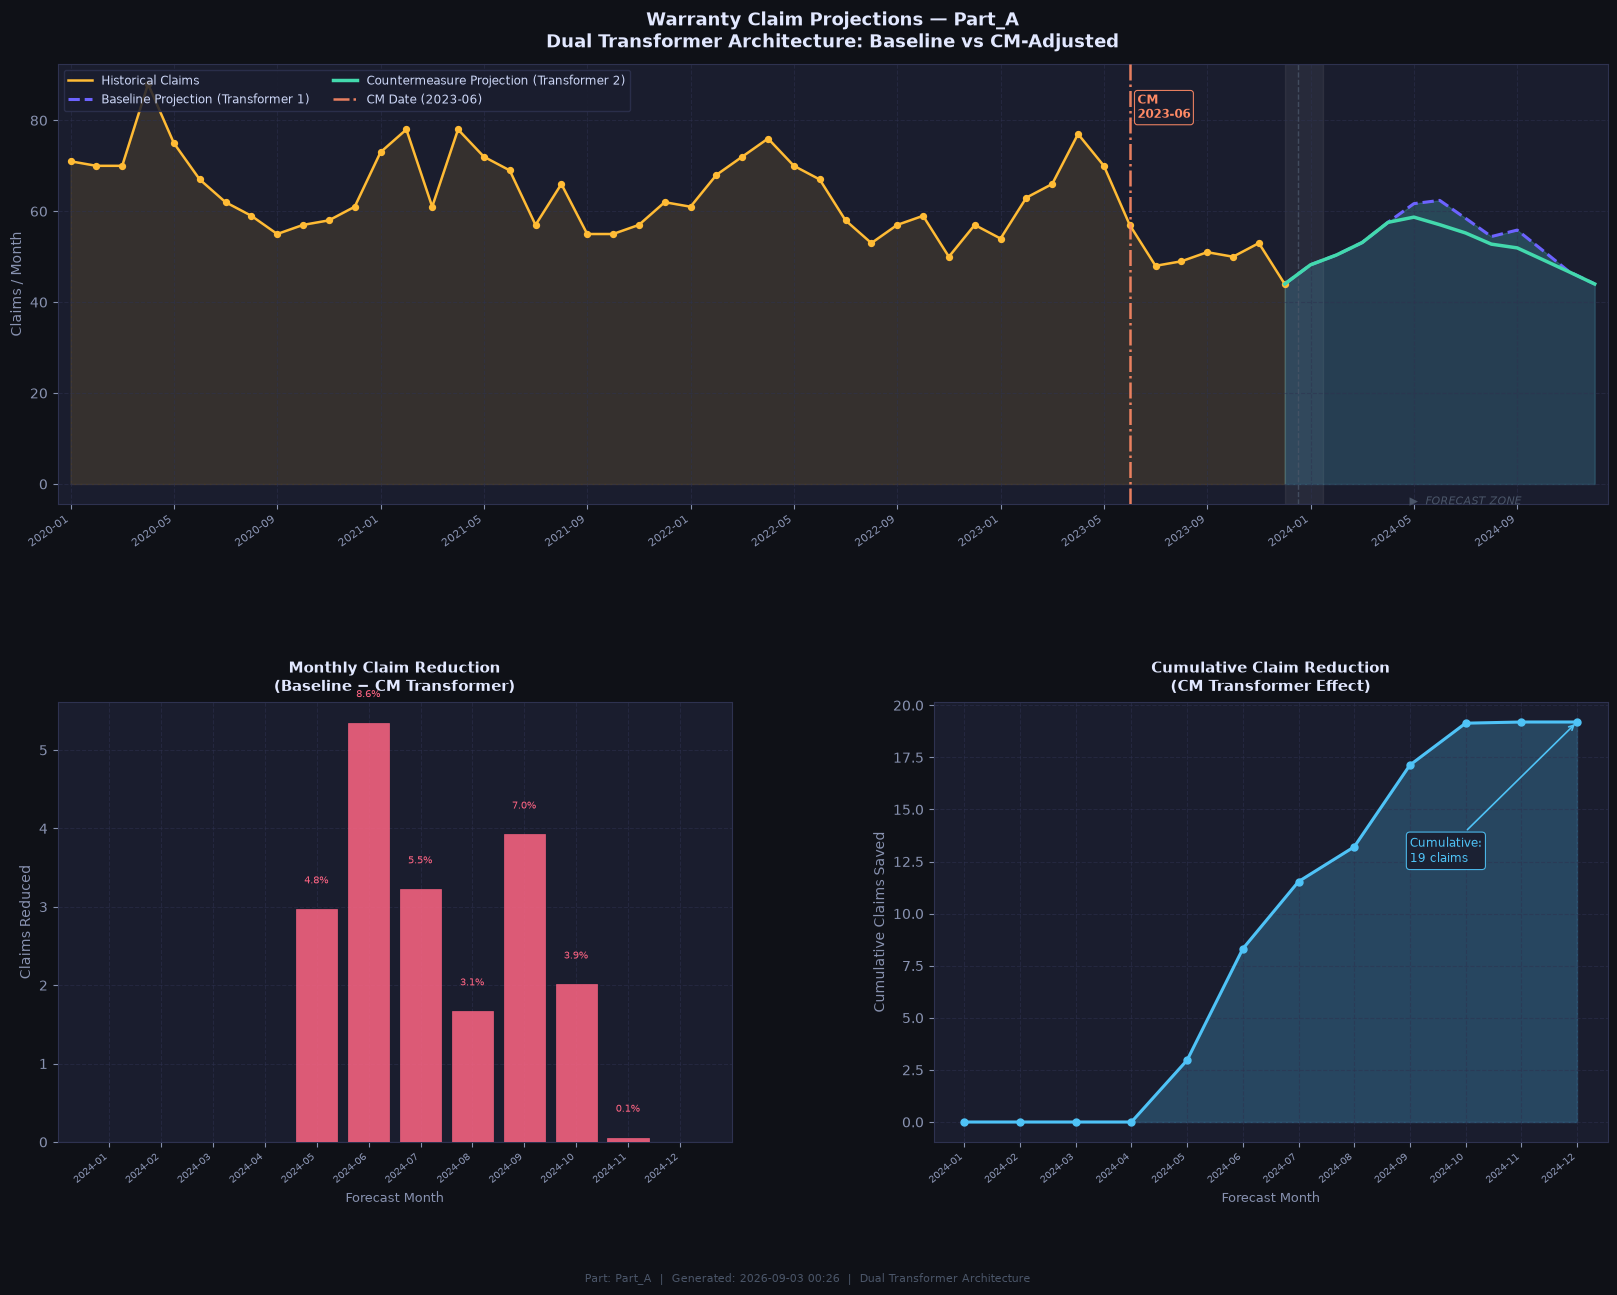

  ✅ Chart saved → .\chart_projections.png


In [32]:
# ============================================================
# CELL 7 — Side-by-side visualisation (4-panel + production)
# ============================================================

def _thin_ticks(labels, max_ticks=14):
    n = len(labels)
    step = max(1, n // max_ticks)
    idxs = list(range(0, n, step))
    return idxs, [labels[i] for i in idxs]


def plot_projections(hist_periods, hist_claims, future_labels,
                     baseline_forecast, cm_forecast, cm_production,
                     comparison, cm_result, part_name,
                     countermeasure_taken, cm_date):
    """4-panel projection dashboard chart."""
    hist_labels = [str(p) for p in hist_periods]
    all_labels  = hist_labels + future_labels
    n_hist      = len(hist_labels)
    n_fc        = len(future_labels)

    fig = plt.figure(figsize=(20, 14), facecolor="#0F1117")
    gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])
    ax_bar  = fig.add_subplot(gs[1, 0])
    ax_cum  = fig.add_subplot(gs[1, 1])
    TC = "#E2E8FF"   # title colour
    SC = "#8892B0"   # subtitle colour

    # ── Panel 1: Historical + Baseline + CM ───────────────────────────────────
    ax = ax_main
    ax.fill_between(range(n_hist), hist_claims, alpha=0.12, color=C_HIST)
    ax.plot(range(n_hist), hist_claims, color=C_HIST, lw=1.8, zorder=3,
            label="Historical Claims")
    ax.scatter(range(n_hist), hist_claims, color=C_HIST, s=18, zorder=4)
    ax.axvspan(n_hist - 1, n_hist + 0.5, alpha=0.06, color="white")
    ax.axvline(n_hist - 0.5, color="#4A5568", ls="--", lw=1.0, alpha=0.8)

    fc_x      = range(n_hist - 1, n_hist + n_fc)
    fc_y_base = np.concatenate([[hist_claims[-1]], baseline_forecast])
    ax.fill_between(fc_x, fc_y_base, alpha=0.10, color=C_BASELINE)
    ax.plot(fc_x, fc_y_base, color=C_BASELINE, lw=2.2, ls="--", zorder=5,
            label="Baseline Projection (Transformer 1)")

    if countermeasure_taken:
        fc_y_cm = np.concatenate([[hist_claims[-1]], cm_forecast])
        ax.fill_between(fc_x, fc_y_cm, alpha=0.15, color=C_CM)
        ax.plot(fc_x, fc_y_cm, color=C_CM, lw=2.5, zorder=6,
                label="Countermeasure Projection (Transformer 2)")
        ax.fill_between(
            np.array(list(fc_x)), fc_y_base, fc_y_cm,
            where=(fc_y_base >= fc_y_cm), alpha=0.20, color=C_CM,
            interpolate=True, label="_nolegend_"
        )
        if cm_date:
            try:
                cm_period = pd.Period(cm_date, freq="M")
                cm_idx = None
                for i, p in enumerate(hist_periods):
                    if pd.Period(p, freq="M") == cm_period:
                        cm_idx = i
                        break
                if cm_idx is None:
                    for j, p in enumerate(future_labels):
                        if pd.Period(p, freq="M") == cm_period:
                            cm_idx = n_hist + j
                            break
                if cm_idx is not None:
                    ax.axvline(cm_idx, color=C_CM_LINE, lw=1.8, ls="-.",
                               alpha=0.9, zorder=7, label=f"CM Date ({cm_date})")
                    ymax = ax.get_ylim()[1]
                    ax.text(cm_idx + 0.3, ymax * 0.93,
                            f"CM\n{cm_date}", color=C_CM_LINE,
                            fontsize=8.5, fontweight="bold", va="top", ha="left",
                            bbox=dict(fc="#1A1D2E", ec=C_CM_LINE, alpha=0.9,
                                      boxstyle="round,pad=0.25", lw=0.8))
            except Exception:
                pass

    ax.text(n_hist + n_fc / 2, ax.get_ylim()[0] * 1.02,
            "▶  FORECAST ZONE", color="#4A5568", ha="center",
            fontsize=8, style="italic")
    ax.set_title(f"Warranty Claim Projections — {part_name}\n"
                 f"Dual Transformer Architecture: Baseline vs CM-Adjusted",
                 color=TC, fontsize=13, fontweight="bold", pad=12)
    xi, xl = _thin_ticks(all_labels)
    ax.set_xticks(xi)
    ax.set_xticklabels(xl, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Claims / Month", color=SC)
    ax.legend(loc="upper left", fontsize=8.5, ncol=2)
    ax.set_xlim(-0.5, len(all_labels) - 0.5)

    # ── Panel 2: Monthly reduction bars ───────────────────────────────────────
    ax = ax_bar
    if countermeasure_taken:
        monthly_red = comparison["monthly_reduction"]
        pct_red     = comparison["pct_reduction"]
        x = np.arange(n_fc)
        bars = ax.bar(x, monthly_red, color=C_REDUCTION, alpha=0.85,
                      edgecolor="#FF6584", lw=0.5, zorder=3)
        for bar, pct in zip(bars, pct_red):
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.3, f"{pct:.1f}%",
                        ha="center", va="bottom", fontsize=7, color=C_REDUCTION)
        ax.set_title("Monthly Claim Reduction\n(Baseline − CM Transformer)",
                     color=TC, fontsize=11, fontweight="bold", pad=8)
        ax.set_xlabel("Forecast Month", color=SC, fontsize=9)
        ax.set_ylabel("Claims Reduced", color=SC)
        ax.set_xticks(x)
        ax.set_xticklabels(future_labels, rotation=40, ha="right", fontsize=7.5)
        ax.axhline(0, color="#4A5568", lw=0.8)
    else:
        ax.text(0.5, 0.5, "No Countermeasure\n(Baseline Only)",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=13, color="#4A5568", style="italic")
        ax.set_title("Monthly Reduction", color=TC, fontsize=11,
                     fontweight="bold", pad=8)

    # ── Panel 3: Cumulative reduction ─────────────────────────────────────────
    ax = ax_cum
    if countermeasure_taken:
        cum_red = comparison["cumulative_reduction"]
        x = np.arange(n_fc)
        ax.fill_between(x, cum_red, alpha=0.25, color=C_CUM)
        ax.plot(x, cum_red, color=C_CUM, lw=2.2, marker="o", markersize=5, zorder=4)
        ax.annotate(
            f"Cumulative:\n{cum_red[-1]:,.0f} claims",
            xy=(x[-1], cum_red[-1]),
            xytext=(max(x[-1] - 3, 0), cum_red[-1] * 0.65),
            fontsize=8.5, color=C_CUM,
            arrowprops=dict(arrowstyle="->", color=C_CUM, lw=1.2),
            bbox=dict(fc="#1A1D2E", ec=C_CUM, alpha=0.9,
                      boxstyle="round,pad=0.3", lw=0.8)
        )
        ax.set_title("Cumulative Claim Reduction\n(CM Transformer Effect)",
                     color=TC, fontsize=11, fontweight="bold", pad=8)
        ax.set_xlabel("Forecast Month", color=SC, fontsize=9)
        ax.set_ylabel("Cumulative Claims Saved", color=SC)
        ax.set_xticks(x)
        ax.set_xticklabels(future_labels, rotation=40, ha="right", fontsize=7.5)
    else:
        ax.text(0.5, 0.5, "No Countermeasure\n(Baseline Only)",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=13, color="#4A5568", style="italic")
        ax.set_title("Cumulative Reduction", color=TC, fontsize=11,
                     fontweight="bold", pad=8)

    ts = datetime.now().strftime("%Y-%m-%d %H:%M")
    fig.text(0.5, 0.01,
             f"Part: {part_name}  |  Generated: {ts}  |  Dual Transformer Architecture",
             ha="center", fontsize=8, color="#4A5568")
    return fig


# ── Render main chart ─────────────────────────────────────────────────────────
fig_main = plot_projections(
    hist_periods         = periods,
    hist_claims          = claims_arr,
    future_labels        = future_labels,
    baseline_forecast    = baseline_forecast,
    cm_forecast          = cm_forecast,
    cm_production        = cm_production,
    comparison           = comparison,
    cm_result            = cm_result,
    part_name            = selected_part,
    countermeasure_taken = COUNTERMEASURE_TAKEN,
    cm_date              = COUNTERMEASURE_DATE if COUNTERMEASURE_TAKEN else None,
)
_chart_main_path = os.path.join(OUTPUT_DIR_NB, "chart_projections.png")
fig_main.savefig(_chart_main_path, dpi=180, bbox_inches="tight",
                 facecolor=fig_main.get_facecolor())
plt.show()
print(f"  ✅ Chart saved → {_chart_main_path}")


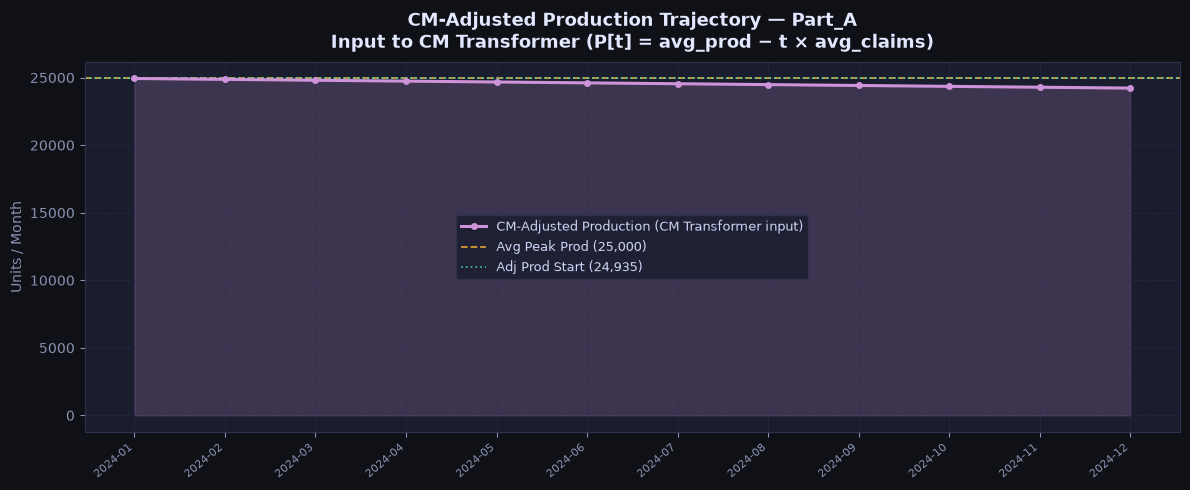

  ✅ Production chart saved → .\chart_production.png


In [33]:
# ── Separate chart: CM-Adjusted Production Trajectory ────────────────────────

def plot_cm_production_trajectory(future_labels, cm_production,
                                   avg_peak_prod, adj_prod, part_name):
    """Standalone production trajectory chart (shown in CM mode only)."""
    fig, ax = plt.subplots(figsize=(12, 5), facecolor="#0F1117")
    ax.set_facecolor("#1A1D2E")
    n = len(future_labels)
    x = np.arange(n)
    ax.fill_between(x, cm_production, alpha=0.20, color=C_PROD)
    ax.plot(x, cm_production, color=C_PROD, lw=2.2, marker="o",
            markersize=4, label="CM-Adjusted Production (CM Transformer input)", zorder=4)
    ax.axhline(avg_peak_prod, color="#FFBB35", lw=1.3, ls="--", alpha=0.8,
               label=f"Avg Peak Prod ({avg_peak_prod:,.0f})")
    ax.axhline(adj_prod, color="#43D9AD", lw=1.3, ls=":", alpha=0.8,
               label=f"Adj Prod Start ({adj_prod:,.0f})")
    ax.set_title(f"CM-Adjusted Production Trajectory — {part_name}\n"
                 f"Input to CM Transformer (P[t] = avg_prod − t × avg_claims)",
                 color="#E2E8FF", fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Units / Month", color="#8892B0")
    ax.set_xticks(x)
    ax.set_xticklabels(future_labels, rotation=40, ha="right", fontsize=8)
    ax.legend(fontsize=9)
    ax.grid(True, color="#2E3250", ls="--", alpha=0.5)
    fig.tight_layout()
    return fig


_chart_prod_path = None
if COUNTERMEASURE_TAKEN and cm_result["cm_active"]:
    fig_prod = plot_cm_production_trajectory(
        future_labels = future_labels,
        cm_production = cm_production,
        avg_peak_prod = cm_result["avg_peak_prod"],
        adj_prod      = cm_result["adj_prod"],
        part_name     = selected_part,
    )
    _chart_prod_path = os.path.join(OUTPUT_DIR_NB, "chart_production.png")
    fig_prod.savefig(_chart_prod_path, dpi=180, bbox_inches="tight",
                     facecolor=fig_prod.get_facecolor())
    plt.show()
    print(f"  ✅ Production chart saved → {_chart_prod_path}")
else:
    print("  ℹ️  Production trajectory chart only shown in CM mode")


---
## 📋 Cell 8 — Numerical Results


In [35]:
# ============================================================
# CELL 8 — Numerical results display
# ============================================================
from IPython.display import display, HTML

def _kpi_html(label, value, unit="", color="#43D9AD"):
    return (
        f'<div style="display:inline-block;margin:8px;padding:16px 24px;'
        f'background:#1A1D2E;border:1px solid {color};border-radius:10px;'
        f'min-width:160px;text-align:center;">'
        f'<div style="color:#8892B0;font-size:11px;margin-bottom:6px;">{label}</div>'
        f'<div style="color:{color};font-size:22px;font-weight:bold;">{value}</div>'
        f'<div style="color:#4A5568;font-size:10px;">{unit}</div>'
        f'</div>'
    )


total_baseline = baseline_forecast.sum()
total_cm       = cm_forecast.sum()
total_red      = comparison["total_reduction"]
total_pct      = comparison["total_pct_reduction"]
total_cost     = comparison["total_cost_savings"]

# ============================================================
# CELL 8 — Numerical results display



# Build KPI HTML block
kpi_html  = '<div style="font-family:DejaVu Sans,sans-serif;">\n'
kpi_html += f'<h3 style="color:#CCD6F6;margin-bottom:10px;">📊 Results — {selected_part}</h3>\n'
kpi_html += _kpi_html("Baseline Total", f"{total_baseline:,.0f}", "claims", "#6C63FF")

if COUNTERMEASURE_TAKEN:
    kpi_html += _kpi_html("CM Total",      f"{total_cm:,.0f}",     "claims",      "#43D9AD")
    kpi_html += _kpi_html("Claims Saved",  f"{total_red:,.0f}",    "claims",      "#FF6584")
    kpi_html += _kpi_html("Reduction",     f"{total_pct:.1f}%",    "of baseline", "#FFBB35")
    if total_cost is not None:
        kpi_html += _kpi_html("Cost Savings", f"${total_cost:,.0f}", "estimated", "#4FC3F7")

kpi_html += '</div>'
display(HTML(kpi_html))

print("\nMonth-by-Month Comparison Table")
print("=" * 75)
comp_df = comparison["comparison_df"].copy()
for col in ["Baseline_Claims", "CM_Claims", "Monthly_Reduction", "Cumulative_Reduction"]:
    comp_df[col] = comp_df[col].round(1)
comp_df["Reduction_%"] = comp_df["Reduction_%"].round(2)
if "Cost_Savings" in comp_df.columns:
    comp_df["Cost_Savings"] = comp_df["Cost_Savings"].round(0)
display(comp_df)

_table_path = os.path.join(OUTPUT_DIR_NB, "comparison_results.csv")
comp_df.to_csv(_table_path, index=False)
print(f"\n  ✅ Results table saved → {_table_path}")

hist_rate = (
    float(np.nanmean(claims_arr / (production_series + 1e-9)))
    if len(production_series) == len(claims_arr)
    else float(np.nanmean(claims_arr)) / DEFAULT_PRODUCTION
)
print("\nClaim Ratio Summary")
print("-" * 40)
print(f"  Historical Claim Rate : {hist_rate:.6f} claims/unit")
print(f"  Per 1,000 units       : {hist_rate * 1000:.2f}")
print(f"  Avg Monthly Claims    : {claims_arr.mean():.1f}")
if COUNTERMEASURE_TAKEN and cm_result["cm_active"]:
    print(f"  Post-CM Avg Forecast  : {cm_forecast.mean():.1f}  (CM Transformer)")
    print(f"  Baseline Avg Forecast : {baseline_forecast.mean():.1f}  (Baseline Transformer)")
    print(f"  Claim Reduction       : {total_pct:.1f}%")



Month-by-Month Comparison Table


,Month,Baseline_Claims,CM_Claims,Monthly_Reduction,Cumulative_Reduction,Reduction_%,Cost_Savings
0,2024-01,48.2,48.2,0.0,0.0,0.00,0.0
1,2024-02,50.4,50.4,0.0,0.0,0.00,0.0
2,2024-03,53.1,53.1,0.0,0.0,0.00,0.0
3,2024-04,57.6,57.6,0.0,0.0,0.00,0.0
4,2024-05,61.7,58.7,3.0,3.0,4.81,2524.0
5,2024-06,62.4,57.0,5.3,8.3,8.57,4543.0
6,2024-07,58.5,55.2,3.2,11.5,5.52,2741.0
7,2024-08,54.4,52.8,1.7,13.2,3.06,1418.0
8,2024-09,55.9,51.9,3.9,17.1,7.02,3335.0
9,2024-10,51.3,49.3,2.0,19.1,3.92,1709.0



  ✅ Results table saved → .\comparison_results.csv

Claim Ratio Summary
----------------------------------------
  Historical Claim Rate : 0.002505 claims/unit
  Per 1,000 units       : 2.50
  Avg Monthly Claims    : 62.6
  Post-CM Avg Forecast  : 52.1  (CM Transformer)
  Baseline Avg Forecast : 53.7  (Baseline Transformer)
  Claim Reduction       : 3.0%


---
## 📑 Cell 9 — PowerPoint Export

Generates a 5-slide deck:
1. **Title slide** with part name and mode
2. **Executive Summary** with KPI cards
3. **Projection Chart** (4-panel main figure)
4. **Production Trajectory** (CM mode only — CM Transformer input)
5. **Month-by-Month Data Table**


In [ ]:
# ============================================================
# CELL 9 — PowerPoint slide export
# ============================================================

def build_pptx_report(part_name, baseline_forecast, cm_forecast,
                       comparison, cm_result, future_labels, hist_claims,
                       chart_main_path, chart_prod_path,
                       countermeasure_taken, cm_date, output_path):
    """Build a 5-slide PowerPoint report."""
    try:
        from pptx import Presentation
        from pptx.util import Inches, Pt
        from pptx.dml.color import RGBColor
        from pptx.enum.text import PP_ALIGN
    except ImportError:
        print("  ⚠️  python-pptx not installed. Run: pip install python-pptx")
        return ""

    BG    = RGBColor(0x0F, 0x11, 0x17)
    BG2   = RGBColor(0x1A, 0x1D, 0x2E)
    WHITE = RGBColor(0xCC, 0xD6, 0xF6)
    GREY  = RGBColor(0x88, 0x92, 0xB0)
    TEAL  = RGBColor(0x43, 0xD9, 0xAD)
    PURP  = RGBColor(0x6C, 0x63, 0xFF)
    ROSE  = RGBColor(0xFF, 0x65, 0x84)
    AMBER = RGBColor(0xFF, 0xBB, 0x35)
    SKY   = RGBColor(0x4F, 0xC3, 0xF7)

    def _set_bg(slide, color=BG):
        f = slide.background.fill
        f.solid()
        f.fore_color.rgb = color

    def _text(slide, text, l, t, w, h, sz=18, bold=False,
               color=WHITE, align=PP_ALIGN.LEFT, italic=False):
        tb = slide.shapes.add_textbox(l, t, w, h)
        tf = tb.text_frame
        tf.word_wrap = True
        p  = tf.paragraphs[0]
        p.alignment = align
        r  = p.add_run()
        r.text = str(text)
        r.font.size    = Pt(sz)
        r.font.bold    = bold
        r.font.italic  = italic
        r.font.color.rgb = color
        return tb

    def _rect(slide, l, t, w, h, rgb):
        s = slide.shapes.add_shape(1, l, t, w, h)
        s.fill.solid()
        s.fill.fore_color.rgb = rgb
        s.line.fill.background()
        return s

    prs = Presentation()
    prs.slide_width  = Inches(13.33)
    prs.slide_height = Inches(7.5)
    blank   = prs.slide_layouts[6]
    ts      = datetime.now().strftime("%Y-%m-%d %H:%M")
    accent  = TEAL if countermeasure_taken else PURP

    # ── Slide 1: Title ─────────────────────────────────────────────────────────
    s1 = prs.slides.add_slide(blank)
    _set_bg(s1)
    _rect(s1, Inches(0), Inches(3.2), Inches(13.33), Inches(0.06), accent)
    _text(s1, "Transformer Projection Report — Dual Architecture",
          Inches(1), Inches(1.5), Inches(11), Inches(1),
          sz=28, bold=True, color=WHITE, align=PP_ALIGN.CENTER)
    _text(s1, f"Part: {part_name}",
          Inches(1), Inches(2.6), Inches(11), Inches(0.6),
          sz=18, color=accent, align=PP_ALIGN.CENTER)
    mode = (f"Baseline Transformer  +  CM Transformer  |  CM Date: {cm_date}"
            if countermeasure_taken else "Baseline Transformer Only")
    _text(s1, mode, Inches(1), Inches(3.4), Inches(11), Inches(0.5),
          sz=13, color=GREY, align=PP_ALIGN.CENTER)
    _text(s1, f"Generated: {ts}", Inches(1), Inches(6.8), Inches(11), Inches(0.4),
          sz=9, color=GREY, align=PP_ALIGN.CENTER, italic=True)

    # ── Slide 2: Executive Summary ─────────────────────────────────────────────
    s2 = prs.slides.add_slide(blank)
    _set_bg(s2)
    _text(s2, "Executive Summary", Inches(0.5), Inches(0.3),
          Inches(12), Inches(0.6), sz=22, bold=True, color=WHITE)
    kpis = [
        ("Forecast Horizon",  f"{len(future_labels)} months",          PURP),
        ("Historical Months", f"{len(hist_claims)}",                   AMBER),
        ("Baseline Total",    f"{baseline_forecast.sum():,.0f} claims", PURP),
    ]
    if countermeasure_taken:
        kpis += [
            ("CM Total Forecast",  f"{cm_forecast.sum():,.0f} claims",              TEAL),
            ("Claims Saved",       f"{comparison['total_reduction']:,.0f}",        ROSE),
            ("Reduction %",        f"{comparison['total_pct_reduction']:.1f}%",    AMBER),
        ]
        if comparison["total_cost_savings"] is not None:
            kpis.append(("Est. Savings",
                          f"${comparison['total_cost_savings']:,.0f}", SKY))
    for idx, (lbl, val, col) in enumerate(kpis):
        row, colpos = divmod(idx, 4)
        bx = Inches(0.4 + colpos * 3.2)
        by = Inches(1.2 + row * 1.9)
        _rect(s2, bx, by, Inches(3.0), Inches(1.6), BG2)
        _rect(s2, bx, by, Inches(3.0), Inches(0.05), col)
        _text(s2, lbl, bx + Inches(0.1), by + Inches(0.15),
              Inches(2.8), Inches(0.35), sz=9, color=GREY)
        _text(s2, val, bx + Inches(0.1), by + Inches(0.6),
              Inches(2.8), Inches(0.7), sz=18, bold=True, color=col)
    if countermeasure_taken and cm_result["cm_active"]:
        _text(s2,
              f"CM Transformer: adj_prod={cm_result['adj_prod']:,.0f}  |  "
              f"avg_peak_prod={cm_result['avg_peak_prod']:,.0f}  |  "
              f"FCOK months={len(cm_result['peak_fcok_df'])}",
              Inches(0.5), Inches(6.8), Inches(12), Inches(0.4),
              sz=9, color=GREY, italic=True)

    # ── Slide 3: Projection Chart ──────────────────────────────────────────────
    s3 = prs.slides.add_slide(blank)
    _set_bg(s3)
    _text(s3, "Projection Chart — Baseline vs CM Transformer",
          Inches(0.3), Inches(0.15), Inches(12.5), Inches(0.5),
          sz=16, bold=True, color=WHITE)
    if os.path.exists(chart_main_path):
        s3.shapes.add_picture(chart_main_path,
                              Inches(0.25), Inches(0.7),
                              Inches(12.8), Inches(6.6))

    # ── Slide 4: Production Trajectory (CM only) ───────────────────────────────
    if countermeasure_taken and chart_prod_path and os.path.exists(chart_prod_path):
        s4 = prs.slides.add_slide(blank)
        _set_bg(s4)
        _text(s4, "CM-Adjusted Production Trajectory (Input to CM Transformer)",
              Inches(0.3), Inches(0.15), Inches(12.5), Inches(0.5),
              sz=16, bold=True, color=WHITE)
        s4.shapes.add_picture(chart_prod_path,
                              Inches(0.4), Inches(0.75),
                              Inches(12.5), Inches(6.2))

    # ── Slide 5: Month-by-Month Table ─────────────────────────────────────────
    s5 = prs.slides.add_slide(blank)
    _set_bg(s5)
    _text(s5, "Month-by-Month Comparison Table",
          Inches(0.3), Inches(0.15), Inches(12.5), Inches(0.5),
          sz=16, bold=True, color=WHITE)
    comp_df = comparison["comparison_df"]
    cols    = list(comp_df.columns)
    n_rows  = len(comp_df)
    tbl = s5.shapes.add_table(
        n_rows + 1, len(cols),
        Inches(0.2), Inches(0.75),
        Inches(12.9), Inches(min(6.5, 0.38 * (n_rows + 1)))
    ).table
    for c, col in enumerate(cols):
        cell = tbl.cell(0, c)
        cell.text = col
        cell.fill.solid()
        cell.fill.fore_color.rgb = RGBColor(0x12, 0x14, 0x22)
        p = cell.text_frame.paragraphs[0]
        p.runs[0].font.size  = Pt(8)
        p.runs[0].font.bold  = True
        p.runs[0].font.color.rgb = TEAL
    for r, (_, row_data) in enumerate(comp_df.iterrows(), start=1):
        for c, col in enumerate(cols):
            cell = tbl.cell(r, c)
            val  = row_data[col]
            cell.text = f"{val:.1f}" if isinstance(val, float) else str(val)
            cell.fill.solid()
            cell.fill.fore_color.rgb = BG2 if r % 2 == 0 else BG
            p = cell.text_frame.paragraphs[0]
            p.runs[0].font.size = Pt(7.5)
            p.runs[0].font.color.rgb = WHITE

    prs.save(output_path)
    return output_path


if EXPORT_PPT:
    _ppt_fname = (
        f"transformer_projection_{selected_part.replace(' ', '_')}"
        f"_{datetime.now().strftime('%Y%m%d_%H%M')}.pptx"
    )
    _ppt_path = os.path.join(OUTPUT_DIR_NB, _ppt_fname)
    result_path = build_pptx_report(
        part_name            = selected_part,
        baseline_forecast    = baseline_forecast,
        cm_forecast          = cm_forecast,
        comparison           = comparison,
        cm_result            = cm_result,
        future_labels        = future_labels,
        hist_claims          = claims_arr,
        chart_main_path      = _chart_main_path,
        chart_prod_path      = _chart_prod_path,
        countermeasure_taken = COUNTERMEASURE_TAKEN,
        cm_date              = COUNTERMEASURE_DATE if COUNTERMEASURE_TAKEN else None,
        output_path          = _ppt_path,
    )
    if result_path:
        print(f"\n✅ PowerPoint saved → {os.path.abspath(result_path)}")
        slides = ["Title", "Executive Summary", "Projection Chart"]
        if COUNTERMEASURE_TAKEN:
            slides.append("Production Trajectory")
        slides.append("Data Table")
        print(f"   Slides: {' | '.join(slides)}")
    else:
        print("  ⚠️  PPT export skipped (install python-pptx to enable)")
else:
    print("  ℹ️  PPT export disabled (EXPORT_PPT = True to enable)")

print()
print("=" * 60)
print("  NOTEBOOK COMPLETE")
print("=" * 60)
print(f"  Part             : {selected_part}")
print(f"  CM Active        : {cm_result['cm_active']}")
print(f"  Baseline Sum     : {baseline_forecast.sum():,.0f} claims  (Transformer 1)")
if cm_result["cm_active"]:
    print(f"  CM Sum           : {cm_forecast.sum():,.0f} claims  (Transformer 2)")
    print(f"  Saved            : {comparison['total_reduction']:,.0f} claims "
          f"({comparison['total_pct_reduction']:.1f}%)")
print("=" * 60)


---
## 🔁 Cell 10 — Edge Case Testing Utilities

Run individual functions below to rapidly test specific scenarios without
re-running the full pipeline.


In [ ]:
# ============================================================
# CELL 10 — Modular edge-case testing utilities
# ============================================================

def quick_test_cm_engine(avg_peak_prod=25_000.0, avg_peak_claims=450.0,
                          horizon=12, cost_per_claim=850.0):
    """Quick unit test of the CM production trajectory logic."""
    print("━" * 55)
    print("  QUICK CM PRODUCTION TRAJECTORY TEST")
    print("━" * 55)
    adj_prod  = max(avg_peak_prod - avg_peak_claims, 1.0)
    cm_prod   = build_cm_adjusted_production(adj_prod, avg_peak_claims, horizon)
    hist_rate = avg_peak_claims / avg_peak_prod
    baseline  = np.full(horizon, avg_peak_claims)
    # Simple rate model for quick test only
    cm_fc     = np.clip(hist_rate * cm_prod, 0, None)
    future_p  = [f"Month {i+1}" for i in range(horizon)]
    result    = compare_forecasts(baseline, cm_fc, future_p, cost_per_claim)

    print(f"  avg_peak_prod   = {avg_peak_prod:,.0f}")
    print(f"  avg_peak_claims = {avg_peak_claims:,.1f}")
    print(f"  adj_prod        = {adj_prod:,.0f}  (= avg_prod − avg_claims)")
    print(f"  hist_rate       = {hist_rate:.5f} claims/unit")
    print()
    print(f"  {'Month':<10} {'CM Prod':>10} {'CM Fc':>8} {'Baseline':>9} {'Reduction':>10}")
    print("  " + "-" * 55)
    for i in range(horizon):
        print(f"  {future_p[i]:<10} {cm_prod[i]:>10,.0f} "
              f"{cm_fc[i]:>8.1f} {baseline[i]:>9.1f} "
              f"{result['monthly_reduction'][i]:>10.1f}")
    print()
    print(f"  Total reduction : {result['total_reduction']:,.0f} claims  "
          f"({result['total_pct_reduction']:.1f}%)")
    if result["total_cost_savings"]:
        print(f"  Cost savings    : ${result['total_cost_savings']:,.0f}")
    print("━" * 55)


def quick_test_dual_transformer(n_months=36, horizon=12, epochs=20, seed=42):
    """Smoke test — fit BOTH Transformers on synthetic sine+noise series."""
    np.random.seed(seed)
    t      = np.arange(n_months)
    claims = 50 + 15 * np.sin(2 * np.pi * t / 12) + np.random.normal(0, 4, n_months)
    claims = np.clip(claims, 1, None)
    periods_t = [str(pd.Period("2021-01", freq="M") + i) for i in range(n_months)]
    prod_t    = np.full(n_months, 25_000.0)

    # ── Baseline features ─────────────────────────────────────────────────────
    feat_df = build_univariate_features(claims, periods_t, production=prod_t)
    feats_t = feat_df[UNI_FEATURE_COLS].to_numpy(dtype=float)
    csc_t = MinMaxScaler(); esc_t = MinMaxScaler()
    ys_t  = csc_t.fit_transform(claims[:, None]).ravel()
    es_t  = esc_t.fit_transform(feats_t)
    W_t = min(12, max(4, n_months // 3))
    H_t = min(horizon, max(1, n_months - W_t - 1))
    X_t, Y_t = build_window_dataset(ys_t, es_t, W_t, H_t)
    if X_t is None:
        print("  ⚠️  Insufficient windows"); return

    last_win = np.concatenate([ys_t[-W_t:, None], es_t[-W_t:]], axis=1)[None]

    # ── Baseline Transformer ──────────────────────────────────────────────────
    print(f"  [T1] Fitting baseline on {n_months}-month series ...")
    m1 = TransformerForecaster(lookback=W_t, n_features=X_t.shape[-1], horizon=H_t,
                                epochs=epochs, seed=seed, early_patience=5)
    m1.fit(X_t, Y_t)
    fc1_sc  = np.clip(m1.predict(last_win)[0], 0, 1)
    fc1     = np.clip(csc_t.inverse_transform(fc1_sc.reshape(-1,1)).ravel(), 0, None)

    # ── CM Transformer (adjusted production) ─────────────────────────────────
    avg_pc = float(claims.mean())
    adj_p  = max(prod_t.mean() - avg_pc, 1.0)
    cm_hp  = build_cm_adjusted_production(adj_p, avg_pc, n_months, WARRANTY_MONTHS)
    feats_cm = feats_t.copy()
    feats_cm[:, UNI_FEATURE_COLS.index("Production_Vol")] = cm_hp
    esc_cm = MinMaxScaler()
    es_cm  = esc_cm.fit_transform(feats_cm)
    X_cm, Y_cm = build_window_dataset(ys_t, es_cm, W_t, H_t)
    last_win_cm = np.concatenate([ys_t[-W_t:, None], es_cm[-W_t:]], axis=1)[None]

    print(f"  [T2] Fitting CM Transformer on {n_months}-month series ...")
    m2 = TransformerForecaster(lookback=W_t, n_features=X_cm.shape[-1], horizon=H_t,
                                epochs=epochs, seed=seed+1, early_patience=5)
    m2.fit(X_cm, Y_cm)
    fc2_sc  = np.clip(m2.predict(last_win_cm)[0], 0, 1)
    fc2     = np.clip(csc_t.inverse_transform(fc2_sc.reshape(-1,1)).ravel(), 0, None)

    print()
    print(f"  Baseline Transformer forecast : {np.round(fc1, 1)}")
    print(f"  CM Transformer forecast       : {np.round(fc2, 1)}")
    print(f"  Baseline mean : {fc1.mean():.1f}  |  CM mean : {fc2.mean():.1f}")
    print(f"  Reduction     : {max(fc1.mean()-fc2.mean(),0):.1f} claims/mo  "
          f"({max((fc1.mean()-fc2.mean())/max(fc1.mean(),1)*100,0):.1f}%)")
    return fc1, fc2


# ── Run tests ─────────────────────────────────────────────────────────────────
print("Running edge case tests ...\n")

# Test 1: CM production trajectory
quick_test_cm_engine(avg_peak_prod=25_000, avg_peak_claims=450,
                     horizon=12, cost_per_claim=850.0)
print()

# Test 2: high-volume part
quick_test_cm_engine(avg_peak_prod=50_000, avg_peak_claims=1_200,
                     horizon=12, cost_per_claim=1_200.0)
print()

# Test 3: Dual Transformer smoke test
print("━" * 55)
print("  DUAL TRANSFORMER SMOKE TEST")
print("━" * 55)
_ = quick_test_dual_transformer(n_months=36, horizon=12, epochs=20)
print("━" * 55)

print("\n✅ All edge case tests complete")
